In [10]:
import pandas as pd
import pybaseball as pyb
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_digits

pd.set_option('display.max_columns', 1000)
pd.set_option('display.max_rows', 1000)

In [2]:
data25 = pd.read_csv('data2025.csv')
data24 = pd.read_csv('data2024.csv')

In [6]:
# all possible out events
outs = [
    'field_out', 'force_out', 'grounded_into_double_play',
    'sac_fly', 'sac_bunt', 'fielders_choice', 'double_play',
    'fielders_choice_out',
    'sac_fly_double_play', 'triple_play', 'popup'
]

swing_code = ['foul_bunt', 'foul', 'hit_into_play', 'swinging_strike', 'foul_tip', 'swinging_strike_blocked', 'missed_bunt', 'bunt_foul_tip']
whiff_code = ['swinging_strike', 'foul_tip', 'swinging_strike_blocked']

out_code = ['field_out', 'grounded_into_double_play', 'force_out', 'sac_bunt',
            'double_play', 'fielders_choice_out', 'sac_fly']

hit_code = ['hit_into_play']



In [4]:
# filter the df down to events that resulted in an out, categorize them
def df_process(df):
    out_data = df[df['events'].isin(outs)].copy()
    out_data['swing'] = (out_data['description'].isin(swing_code))
    out_data['whiff'] = (out_data['description'].isin(whiff_code))

    out_data['out_type'] = out_data.apply(categorize_out, axis=1)
    out_data = out_data[out_data['out_type'] != 'other']
    return out_data

def categorize_out(row):
    if row['bb_type'] in ['ground_ball']:
        return 'groundout'
    elif row['bb_type'] in ['fly_ball', 'line_drive', 'popup']:
        return 'flyout'
    else:
        return None



In [5]:
def get_features(out_data, features):
    model_data = out_data[features].dropna()

    cat_cols = ['pitch_name', 'stand', 'p_throws']
    model_data = pd.get_dummies(model_data, columns=cat_cols, drop_first=True)
    return model_data

### Without Launch Angle

In [6]:
features = [
    'pitch_name',
    'pfx_x', 'pfx_z', 'plate_x', 'plate_z', 'balls', 'strikes', 'zone',
    'stand', 'p_throws', 'release_speed', 'release_spin_rate', 'spin_axis', 'release_extension', 'release_pos_y', 
    'swing_path_tilt', 'arm_angle', 'delta_run_exp', 'swing', 'whiff'
]
out_data = df_process(data25)
model_data = get_features(out_data, features)


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge  


X = model_data.drop(columns=['delta_run_exp'])
y = model_data['delta_run_exp']


X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

pipe = make_pipeline(StandardScaler(),
                     Ridge(alpha=1.0))
pipe.fit(X_train, y_train)


Pipeline(steps=[('standardscaler', StandardScaler()), ('ridge', Ridge())])

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
y_pred = pipe.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

RMSE: 0.06294702683090633
MAE: 0.027429532570416287
R²: 0.3991641744630351


In [ ]:


X = model_data.drop(columns=['delta_run_exp'])
y = model_data['delta_run_exp']


train_X, test_X, train_y, test_y = train_test_split(X, y, 
                                                    test_size = 0.25, 
                                                    random_state = 42)

gbr = GradientBoostingRegressor(
    n_estimators=400,    
    learning_rate=0.05,   
    max_depth=3,          
    min_samples_split=5,
    min_samples_leaf=3,
    subsample=0.8,        
    random_state=42
)                                 
gbr.fit(train_X, train_y)

pred_y = gbr.predict(test_X)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

RMSE: 0.06294702683090633
MAE: 0.027429532570416287
R²: 0.3991641744630351


In [10]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': gbr.feature_importances_
}).sort_values('importance', ascending=False)

print(importance)


                     feature  importance
4                      balls    0.488203
5                    strikes    0.408105
12           swing_path_tilt    0.056807
3                    plate_z    0.009597
8          release_spin_rate    0.005764
13                 arm_angle    0.005041
7              release_speed    0.004952
11             release_pos_y    0.004435
1                      pfx_z    0.004010
0                      pfx_x    0.003576
9                  spin_axis    0.003068
2                    plate_x    0.002711
6                       zone    0.000932
21  pitch_name_Knuckle Curve    0.000908
25         pitch_name_Sinker    0.000430
10         release_extension    0.000425
30        pitch_name_Sweeper    0.000389
28         pitch_name_Slurve    0.000205
27     pitch_name_Slow Curve    0.000167
29   pitch_name_Split-Finger    0.000159
32                p_throws_R    0.000066
31                   stand_R    0.000034
16       pitch_name_Changeup    0.000014
17      pitch_na

In [11]:
# y_pred = pipe.predict(X_test)
# # print(classification_report(y_test, y_pred))
# cm = confusion_matrix(y_test, y_pred)
# print(cm)

In [12]:
import joblib
model_name = 'logistic_regression_model.joblib'
joblib.dump(pipe, model_name)

['logistic_regression_model.joblib']

In [13]:
loaded_model = joblib.load('logistic_regression_model.joblib')

In [ ]:
#testing with all 2024 data
processed_data_24 = df_process(data24)
model_data = get_features(processed_data_24, features)
new_x = model_data.drop(columns=['out_type'])
y_true = model_data['out_type']

y_pred = loaded_model.predict(new_x)

print(classification_report(y_true, y_pred))
cm = confusion_matrix(y_true, y_pred)
print(cm)


### Adding Launch Angle as a feature

In [15]:
la_features = [
    'pitch_name',
    'pfx_x', 'pfx_z', 'plate_x', 'plate_z', 'balls', 'strikes', 'zone',
    'stand', 'p_throws', 'release_speed', 'release_spin_rate', 'spin_axis', 'release_extension', 'release_pos_y', 'out_type', 
    'swing_path_tilt', 'attack_angle', 'attack_direction', 'arm_angle', 'swing_length', 'bat_speed',
    'launch_angle'
]
out_data = df_process(data25)
model_data = get_features(out_data, la_features)

X = model_data.drop(columns=['out_type'])
y = model_data['out_type']


X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

pipe = make_pipeline(StandardScaler(),
                     LogisticRegression())
pipe.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression())])

In [16]:
y_pred = pipe.predict(X_test)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)

              precision    recall  f1-score   support

      flyout       0.98      0.97      0.97     10710
   groundout       0.96      0.98      0.97      9051

    accuracy                           0.97     19761
   macro avg       0.97      0.97      0.97     19761
weighted avg       0.97      0.97      0.97     19761

[[10357   353]
 [  190  8861]]


### Can we predict a swing based on pitch type and location?

In [ ]:
def df_swing_process(df):
    df['swing'] = (df['description'].isin(swing_code))
    df['whiff'] = (df['description'].isin(whiff_code))
    df['count_str'] = df['balls'].astype(str) + '-' + df['strikes'].astype(str)

    df['prev_pitch_name'] = df.groupby(['game_pk','at_bat_number'])['pitch_name'].shift(1)

    df['prev_swing'] = df.groupby(['game_pk','at_bat_number'])['swing'].shift(1)
    df['prev_whiff'] = df.groupby(['game_pk','at_bat_number'])['whiff'].shift(1)
    df['prev_zone']  = df.groupby(['game_pk','at_bat_number'])['zone'].shift(1)

    df['delta_vel'] = df['release_speed'] - df.groupby(['game_pk','at_bat_number'])['release_speed'].shift(1)
    df['delta_pfx_z'] = df['pfx_z'] - df.groupby(['game_pk','at_bat_number'])['pfx_z'].shift(1)
    df['delta_zone'] = df['zone'] - df.groupby(['game_pk','at_bat_number'])['zone'].shift(1)
    
    pitcher_stats = df.groupby('pitcher')['swing'].mean().rename('pitcher_induced_swing_rate')

    df['men_on'] = (df['on_1b'].notna().astype(int)
                + df['on_2b'].notna().astype(int)
                + df['on_3b'].notna().astype(int))

    df['score_diff'] = df['bat_score'] - df['fld_score']

    df['dist_center'] = np.sqrt(df['plate_x']**2 + df['plate_z']**2)
    df['is_edge'] = (df['dist_center'] > 0.7).astype(int)

    df['in_zone'] = df['zone'].between(1, 9)
    df['out_zone'] = ~df['in_zone']

    df['chase_pitch'] = df['out_zone']

    df['chase_swing'] = df['chase_pitch'] & df['swing']

    df['zone_pitch'] = df['in_zone']
    df['zone_swing'] = df['zone_pitch'] & df['swing']

    df['first_pitch'] = (df['balls'] == 0) & (df['strikes'] == 0)
    df['first_pitch_swing'] = df['first_pitch'] & df['swing']

    df['two_strike'] = df['strikes'] == 2
    df['two_strike_swing'] = df['two_strike'] & df['swing']

    batter_stats = df.groupby('batter').agg(
        batter_swing_rate=('swing', 'mean'),
        batter_whiff_rate=('whiff', 'mean'),
        
        chase_swings=('chase_swing', 'sum'),
        chase_pitches=('chase_pitch', 'sum'),
        
        zone_swings=('zone_swing', 'sum'),
        zone_pitches=('zone_pitch', 'sum'),
        
        first_pitch_swings=('first_pitch_swing', 'sum'),
        first_pitch_pitches=('first_pitch', 'sum'),
        
        two_strike_swings=('two_strike_swing', 'sum'),
        two_strike_pitches=('two_strike', 'sum'),
    )

    batter_stats['batter_chase_rate'] = (
        batter_stats['chase_swings'] / batter_stats['chase_pitches'].replace(0, np.nan)
    )

    batter_stats['batter_zone_swing_rate'] = (
        batter_stats['zone_swings'] / batter_stats['zone_pitches'].replace(0, np.nan)
    )

    batter_stats['batter_first_pitch_swing_rate'] = (
        batter_stats['first_pitch_swings'] / batter_stats['first_pitch_pitches'].replace(0, np.nan)
    )

    batter_stats['batter_two_strike_swing_rate'] = (
        batter_stats['two_strike_swings'] / batter_stats['two_strike_pitches'].replace(0, np.nan)
    )

    df['plate_z_rel'] = (df['plate_z'] - ((df['sz_top'] + df['sz_bot']) / 2))
    df['above_zone'] = (df['plate_z'] > df['sz_top']).astype(int)
    df['below_zone'] = (df['plate_z'] < df['sz_bot']).astype(int)

    df['dist_edge'] = np.minimum(
        np.abs(df['plate_x']) - 0.95/2,   
        np.abs(df['plate_z'] - df['sz_bot']),
    )
    df['is_borderline'] = (df['dist_edge'].between(-0.2, 0.1)).astype(int)

    df['delta_plate_x'] = df['plate_x'] - df.groupby(['game_pk','at_bat_number'])['plate_x'].shift(1)
    df['delta_plate_z'] = df['plate_z'] - df.groupby(['game_pk','at_bat_number'])['plate_z'].shift(1)
    df['big_movement_change'] = (df['delta_plate_x'].abs() + df['delta_plate_z'].abs() > 1.0).astype(int)

    pitcher_stats = df.groupby('pitcher').agg(
        pitcher_zone_rate=('in_zone', 'mean'),
        pitcher_first_pitch_zone=('first_pitch', lambda x: df.loc[x.index][x]['in_zone'].mean()),
    )


    df = df.merge(pitcher_stats, on='pitcher', how='left')

    df = df.merge(batter_stats, on='batter', how='left')



    return df

swing_features = [
    'pitch_name',
    'pfx_x', 'pfx_z', 'plate_x', 'plate_z', 'balls', 'strikes', 'zone',
    'stand', 'p_throws', 'release_speed', 'release_spin_rate', 'spin_axis','swing', 
    'count_str', 'prev_pitch_name', 'prev_swing', 'prev_whiff', 'prev_zone', 'delta_vel', 'delta_pfx_z',
    'men_on', 'score_diff', 'is_edge', 'delta_zone', 'dist_center', 
    'batter_chase_rate', 'batter_zone_swing_rate', 'batter_first_pitch_swing_rate', 'batter_two_strike_swing_rate',
    'plate_z_rel', 'above_zone', 'below_zone', 'dist_edge', 'is_borderline', 'delta_plate_x', 'delta_plate_z', 'big_movement_change'
]

In [89]:
def get_swing_features(model_data, features):
    model_data = model_data[features].dropna()

    cat_cols = ['pitch_name', 'stand', 'p_throws', 'count_str', 'prev_pitch_name']
    model_data = pd.get_dummies(model_data, columns=cat_cols, drop_first=True)
    return model_data

In [ ]:
process_data = df_swing_process(data25)
model_data = get_swing_features(process_data, swing_features)


cols_to_fix = ['prev_swing', 'prev_whiff']

for col in cols_to_fix:
    model_data[col] = model_data[col].map({True: 1, False: 0, 'True': 1, 'False': 0})
    
    model_data[col] = model_data[col].fillna(0).astype('int64')

bool_cols = model_data.select_dtypes(include=['bool']).columns
model_data[bool_cols] = model_data[bool_cols].astype('int64')

X = model_data.drop(columns=['swing'])
y = model_data['swing']

X_train_swing, X_test_swing, y_train_swing, y_test_swing = train_test_split(X, y, random_state=42, stratify=y)


ratio = (y_train_swing == 0).sum() / (y_train_swing == 1).sum()

swing_model = XGBClassifier(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=7,
    min_child_weight=3,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=1.0,
    reg_alpha=0.0,
    reg_lambda=2.0,
    scale_pos_weight=ratio,
    objective='binary:logistic',
    eval_metric='aucpr',  
    tree_method='hist',
    random_state=42
)

swing_model.fit(X_train_swing, y_train_swing)
y_prob_swing = swing_model.predict_proba(X_test_swing)[:, 1]
y_pred_swing = (y_prob_swing > 0.65).astype(int)   

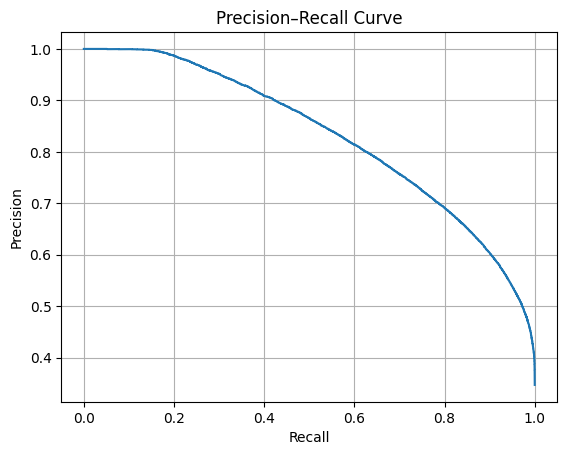

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test_swing, y_prob_swing)
import pandas as pd

pr_df = pd.DataFrame({
    'threshold': thresholds,
    'precision': precision[:-1], 
    'recall': recall[:-1]
})

pr_df.head()

plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve')
plt.grid()
plt.show()

### Can we predict Groundouts and flyouts? 

In [ ]:
df = data25.copy()

bip = df[df['description'] == 'hit_into_play'].copy()
bip = bip[bip['bb_type'].isin(['ground_ball', 'fly_ball', 'line_drive', 'popup'])].copy()

bip = df_swing_process(bip)

bb_map = {
    'ground_ball': 0,
    'fly_ball':    1,
    'line_drive':  2,
    'popup':       3
}
bip['y_bb'] = bip['bb_type'].map(bb_map)

feature_cols = [
    'pitch_name',
    'pfx_x', 'pfx_z',
    'plate_x', 'plate_z',
    'release_speed', 'release_spin_rate', 'spin_axis',
    'stand', 'p_throws', 'count_str',
    
    'balls', 'strikes', 'outs_when_up', 'inning',
    'on_1b', 'on_2b', 'on_3b',

    'batter_chase_rate',
    'batter_zone_swing_rate',
    'batter_first_pitch_swing_rate',
    'batter_two_strike_swing_rate',

    'prev_pitch_name', 'prev_zone', 'delta_vel'
]
model_data = bip[feature_cols + ['y_bb']].copy()

for col in ['on_1b', 'on_2b', 'on_3b']:
    if col in model_data.columns:
        model_data[col] = model_data[col].notna().astype(int)

if 'delta_vel' in model_data.columns:
    model_data['delta_vel'] = model_data['delta_vel'].fillna(0)

if 'prev_zone' in model_data.columns:
    model_data['prev_zone'] = model_data['prev_zone'].fillna(0)

for col in [
    'batter_chase_rate',
    'batter_zone_swing_rate',
    'batter_first_pitch_swing_rate',
    'batter_two_strike_swing_rate'
]:
    if col in model_data.columns:
        model_data[col] = model_data[col].fillna(model_data[col].mean())

model_data = model_data.dropna(subset=['y_bb'])

cat_cols = [c for c in ['pitch_name', 'stand', 'p_throws', 'count_str', 'prev_pitch_name']
            if c in model_data.columns]

model_data = pd.get_dummies(model_data, columns=cat_cols, drop_first=True)

X = model_data.drop(columns=['y_bb'])
y = model_data['y_bb']

print("X shape:", X.shape)
print("Class distribution (0=GB, 1=FB, 2=LD, 3=PU):")
print(y.value_counts())


X shape: (124129, 48)
Class distribution (0=GB, 1=FB, 2=LD, 3=PU):
y_bb
0    52585
1    33074
2    29714
3     8756
Name: count, dtype: int64


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb_bb = XGBClassifier(
    objective='multi:softprob',
    num_class=4,              
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    tree_method='hist',
    eval_metric='mlogloss',
    random_state=42
)

xgb_bb.fit(X_train, y_train)

y_pred = xgb_bb.predict(X_test)

print(classification_report(
    y_test,
    y_pred,
    target_names=['GB', 'FB', 'LD', 'PU']
))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

          GB       0.50      0.80      0.62     10517
          FB       0.38      0.45      0.41      6615
          LD       0.27      0.02      0.03      5943
          PU       0.34      0.02      0.03      1751

    accuracy                           0.46     24826
   macro avg       0.37      0.32      0.27     24826
weighted avg       0.40      0.46      0.38     24826

[[8363 2010  124   20]
 [3513 2974  101   27]
 [3964 1873   95   11]
 [ 788  903   30   30]]


### GB vs Non GB and FB vs Non FB


In [ ]:
process_data = df_swing_process(data25.copy())

bip = process_data[
    (process_data['description'] == 'hit_into_play') &
    (process_data['bb_type'].isin(['ground_ball', 'fly_ball', 'line_drive', 'popup']))
].copy()

bip['y_gb'] = (bip['bb_type'] == 'ground_ball').astype(int)
bip['y_fb'] = (bip['bb_type'] == 'fly_ball').astype(int)

out_features = [f for f in swing_features if f != 'swing']


def get_out_features(df, features, target_col):
    """
    Build a clean feature matrix for an out-type model (GB vs non-GB, FB vs non-FB)
    using the same style as get_swing_features but adapted for these targets.
    """
    model_data = df[features + [target_col]].copy()


    for col in ['prev_swing', 'prev_whiff']:
        if col in model_data.columns:
            model_data[col] = model_data[col].map({True: 1, False: 0, 'True': 1, 'False': 0})
            model_data[col] = model_data[col].fillna(0).astype('int64')

    for col in ['on_1b', 'on_2b', 'on_3b']:
        if col in model_data.columns:
            model_data[col] = model_data[col].notna().astype(int)

    for col in ['prev_zone', 'delta_vel', 'delta_pfx_z', 'delta_zone', 'delta_plate_x', 'delta_plate_z']:
        if col in model_data.columns:
            model_data[col] = model_data[col].fillna(0)

    for col in [
        'batter_chase_rate',
        'batter_zone_swing_rate',
        'batter_first_pitch_swing_rate',
        'batter_two_strike_swing_rate'
    ]:
        if col in model_data.columns:
            model_data[col] = model_data[col].fillna(model_data[col].mean())

    bool_cols = model_data.select_dtypes(include=['bool']).columns
    model_data[bool_cols] = model_data[bool_cols].astype('int64')

    model_data = model_data.dropna(subset=[target_col])
    cat_cols = [c for c in ['pitch_name', 'stand', 'p_throws', 'count_str', 'prev_pitch_name']
                if c in model_data.columns]
    model_data = pd.get_dummies(model_data, columns=cat_cols, drop_first=True)

    return model_data


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
import numpy as np

gb_data = get_out_features(bip, out_features, target_col='y_gb')

X_gb = gb_data.drop(columns=['y_gb'])
y_gb = gb_data['y_gb']

print("GB dataset shape:", X_gb.shape)
print("GB class distribution (0=non-GB, 1=GB):")
print(y_gb.value_counts())

X_train_gb, X_test_gb, y_train_gb, y_test_gb = train_test_split(
    X_gb, y_gb, test_size=0.2, random_state=42, stratify=y_gb
)

ratio_gb = (y_train_gb == 0).sum() / (y_train_gb == 1).sum()

gb_model = XGBClassifier(
    objective='binary:logistic',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=1.0,
    reg_lambda=2.0,
    scale_pos_weight=ratio_gb,
    eval_metric='aucpr',
    tree_method='hist',
    random_state=42
)

gb_model.fit(X_train_gb, y_train_gb)

# 
gb_prob = gb_model.predict_proba(X_test_gb)[:, 1]
gb_pred = (gb_prob > 0.5).astype(int)  

print("=== Ground ball vs non-ground ball ===")
print(classification_report(y_test_gb, gb_pred, target_names=['non-GB', 'GB']))
print(confusion_matrix(y_test_gb, gb_pred))


GB dataset shape: (124129, 60)
GB class distribution (0=non-GB, 1=GB):
y_gb
0    71544
1    52585
Name: count, dtype: int64
=== Ground ball vs non-ground ball ===
              precision    recall  f1-score   support

      non-GB       0.70      0.67      0.68     14309
          GB       0.57      0.61      0.59     10517

    accuracy                           0.64     24826
   macro avg       0.64      0.64      0.64     24826
weighted avg       0.65      0.64      0.64     24826

[[9518 4791]
 [4066 6451]]


In [ ]:
fb_data = get_out_features(bip, out_features, target_col='y_fb')

X_fb = fb_data.drop(columns=['y_fb'])
y_fb = fb_data['y_fb']

print("FB dataset shape:", X_fb.shape)
print("FB class distribution (0=non-FB, 1=FB):")
print(y_fb.value_counts())

X_train_fb, X_test_fb, y_train_fb, y_test_fb = train_test_split(
    X_fb, y_fb, test_size=0.2, random_state=42, stratify=y_fb
)

ratio_fb = (y_train_fb == 0).sum() / (y_train_fb == 1).sum()

fb_model = XGBClassifier(
    objective='binary:logistic',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=1.0,
    reg_lambda=2.0,
    scale_pos_weight=ratio_fb,
    eval_metric='aucpr',
    tree_method='hist',
    random_state=42
)

fb_model.fit(X_train_fb, y_train_fb)

fb_prob = fb_model.predict_proba(X_test_fb)[:, 1]
fb_pred = (fb_prob > 0.5).astype(int)

print("=== Fly ball vs non-fly ball ===")
print(classification_report(y_test_fb, fb_pred, target_names=['non-FB', 'FB']))
print(confusion_matrix(y_test_fb, fb_pred))


FB dataset shape: (124129, 60)
FB class distribution (0=non-FB, 1=FB):
y_fb
0    91055
1    33074
Name: count, dtype: int64
=== Fly ball vs non-fly ball ===
              precision    recall  f1-score   support

      non-FB       0.82      0.61      0.70     18211
          FB       0.37      0.63      0.46      6615

    accuracy                           0.61     24826
   macro avg       0.59      0.62      0.58     24826
weighted avg       0.70      0.61      0.63     24826

[[11038  7173]
 [ 2451  4164]]


In [ ]:
def evaluate_pitch(x_row):
    """
    x_row must be a single-row DataFrame with the same columns as X_gb/X_fb/X_swing.
    """
    p_swing = swing_model.predict_proba(x_row)[0, 1]
    p_gb    = gb_model.predict_proba(x_row[X_gb.columns])[0, 1]
    p_fb    = fb_model.predict_proba(x_row[X_fb.columns])[0, 1]

    GB_OUT = 0.76
    FB_OUT = 0.22

    expected_groundout = p_swing * p_gb * GB_OUT
    expected_flyout    = p_swing * p_fb * FB_OUT

    return {
        'P_swing': p_swing,
        'P_GB': p_gb,
        'P_FB': p_fb,
        'Expected_groundout': expected_groundout,
        'Expected_flyout': expected_flyout
    }


### Expected Launch Angle??

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

df = df_swing_process(data25.copy())

la_df = df[
    (df['description'] == 'hit_into_play') &
    (df['launch_angle'].notna())
].copy()


In [ ]:
la_features = [
    'pitch_name',
    'pfx_x', 'pfx_z',
    'plate_x', 'plate_z',
    'release_speed', 'release_spin_rate', 'spin_axis',
    'stand', 'p_throws', 'count_str',

    'balls', 'strikes', 'outs_when_up', 'inning',
    'on_1b', 'on_2b', 'on_3b',

    'batter_chase_rate',
    'batter_zone_swing_rate',
    'batter_first_pitch_swing_rate',
    'batter_two_strike_swing_rate',

    'prev_pitch_name', 'prev_zone', 'delta_vel',
]


In [ ]:
def get_la_features(df, features, target_col='launch_angle_clipped'):
    model_data = df[features + [target_col]].copy()

    for col in ['on_1b', 'on_2b', 'on_3b']:
        if col in model_data.columns:
            model_data[col] = model_data[col].notna().astype(int)

    for col in ['prev_zone', 'delta_vel']:
        if col in model_data.columns:
            model_data[col] = model_data[col].fillna(0)

    for col in [
        'batter_chase_rate',
        'batter_zone_swing_rate',
        'batter_first_pitch_swing_rate',
        'batter_two_strike_swing_rate'
    ]:
        if col in model_data.columns:
            model_data[col] = model_data[col].fillna(model_data[col].mean())

    bool_cols = model_data.select_dtypes(include=['bool']).columns
    model_data[bool_cols] = model_data[bool_cols].astype('int64')

    model_data = model_data.dropna(subset=[target_col])

    cat_cols = [c for c in ['pitch_name', 'stand', 'p_throws', 'count_str', 'prev_pitch_name']
                if c in model_data.columns]
    model_data = pd.get_dummies(model_data, columns=cat_cols, drop_first=True)

    return model_data

la_model_data = get_la_features(la_df, la_features, target_col='launch_angle_clipped')

X_la = la_model_data.drop(columns=['launch_angle_clipped'])
y_la = la_model_data['launch_angle_clipped']


In [99]:
X_train_la, X_test_la, y_train_la, y_test_la = train_test_split(
    X_la, y_la, test_size=0.2, random_state=42
)

la_model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42
)

la_model.fit(X_train_la, y_train_la)

y_pred_la = la_model.predict(X_test_la)

mae = mean_absolute_error(y_test_la, y_pred_la)
rmse = mean_absolute_error(y_test_la, y_pred_la) ** 0.5
r2 = r2_score(y_test_la, y_pred_la)

print(f"MAE:  {mae:.2f} degrees")
print(f"RMSE: {rmse:.2f} degrees (approx)")
print(f"R²:   {r2:.3f}")


MAE:  20.52 degrees
RMSE: 4.53 degrees (approx)
R²:   0.152
